In [82]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input , Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os


In [2]:

os.environ["OMP_NUM_THREADS"] = "12"
os.environ["TF_NUM_INTRAOP_THREADS"] = "12"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

tf.config.threading.set_intra_op_parallelism_threads(12)
tf.config.threading.set_inter_op_parallelism_threads(2)

print("Intra-op:", tf.config.threading.get_intra_op_parallelism_threads())
print("Inter-op:", tf.config.threading.get_inter_op_parallelism_threads())


Intra-op: 12
Inter-op: 2


In [3]:
df = pd.read_csv('../../../datasets/forest_cover.csv')

In [4]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [5]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Wilderness_Area2', 'Wilderness_Area3',
       'Wilderness_Area4

In [57]:
df.dropna(inplace=True)

In [58]:
x = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [60]:
scaler = StandardScaler()

In [61]:
numerical_col = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']

x_train[numerical_col] = scaler.fit_transform(x_train[numerical_col])
x_test[numerical_col] = scaler.transform(x_test[numerical_col])

In [62]:
y_train = y_train - 1
y_test = y_test - 1

In [63]:
y_train.unique()

array([1, 0, 6, 5, 2, 3, 4])

In [101]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu', ))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', ))
model.add(Dropout(0.4))
model.add(Dense(7, activation='softmax'))

In [102]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [103]:
callbacks = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [112]:
history = model.fit(x_train, y_train, validation_split=0.2, epochs=50, batch_size=256, callbacks=callbacks)

Epoch 1/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9051 - loss: 0.2330 - val_accuracy: 0.9318 - val_loss: 0.1673
Epoch 2/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9045 - loss: 0.2341 - val_accuracy: 0.9331 - val_loss: 0.1657
Epoch 3/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9046 - loss: 0.2341 - val_accuracy: 0.9324 - val_loss: 0.1668
Epoch 4/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9052 - loss: 0.2335 - val_accuracy: 0.9333 - val_loss: 0.1677
Epoch 5/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9051 - loss: 0.2340 - val_accuracy: 0.9316 - val_loss: 0.1683
Epoch 6/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9052 - loss: 0.2332 - val_accuracy: 0.9332 - val_loss: 0.1683
Epoch 7/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9047 - loss: 0.2342 - val_accuracy: 0.9325 - val_loss: 0.1675
Epoch 8/50
1453/1453 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9050 -

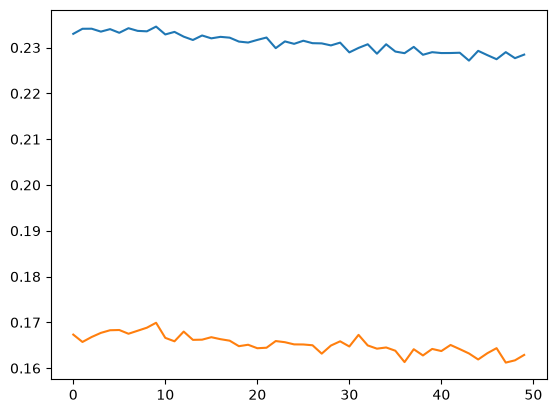

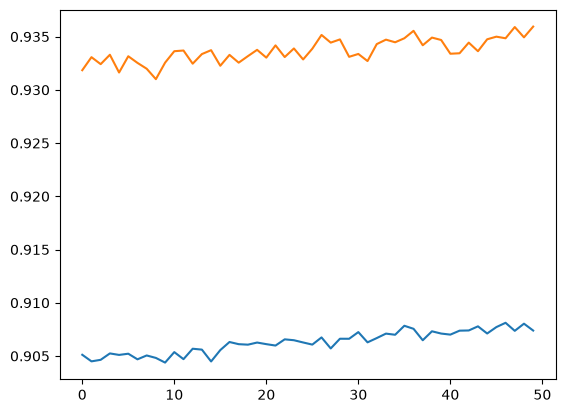

In [113]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [114]:
y_prob = model.predict(x_test)
y_pred = y_prob.argmax(axis=1)

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [115]:
accuracy_score(y_test, y_pred)

0.9368777053948694